In [2]:
# !pip install numpy torch cvxpy cvxpylayers gurobipy matplotlib tqdm


Beginning Cross-Instance Time Evaluation Sweep!

  GENERATING VEHICLE INSTANCE 1/5
Generating Datasets for Instance 1...
Evaluating True MIQCQP times...
Training and Evaluating Standard NN...
Training and Evaluating DF Surrogate...
  GENERATING VEHICLE INSTANCE 2/5
Generating Datasets for Instance 2...
Evaluating True MIQCQP times...
Training and Evaluating Standard NN...
Training and Evaluating DF Surrogate...
  GENERATING VEHICLE INSTANCE 3/5
Generating Datasets for Instance 3...
Evaluating True MIQCQP times...
Training and Evaluating Standard NN...
Training and Evaluating DF Surrogate...
  GENERATING VEHICLE INSTANCE 4/5
Generating Datasets for Instance 4...
Evaluating True MIQCQP times...
Training and Evaluating Standard NN...
Training and Evaluating DF Surrogate...
  GENERATING VEHICLE INSTANCE 5/5
Generating Datasets for Instance 5...
Evaluating True MIQCQP times...
Training and Evaluating Standard NN...
Training and Evaluating DF Surrogate...

Sweep Finished! Generating CDF Time

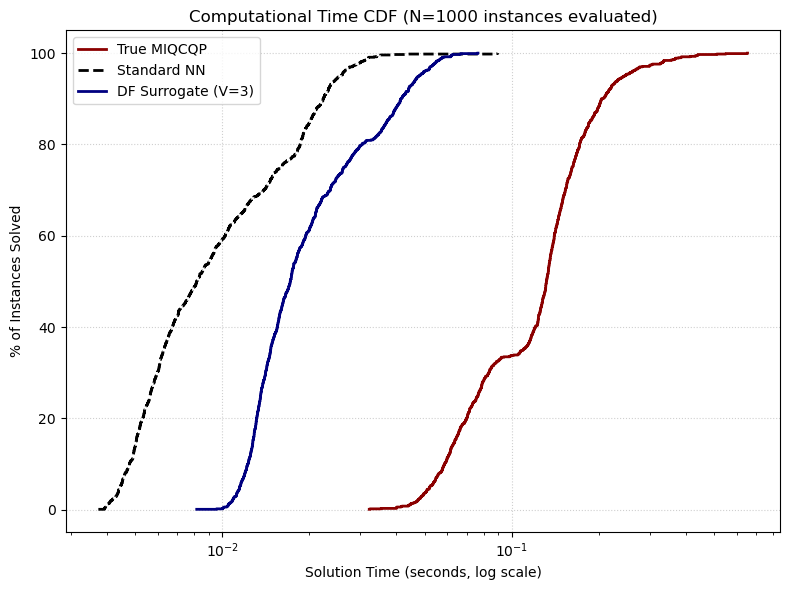

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import time
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore", message="Solved/Inaccurate")

# ==============================================================================
# 0. HYPERPARAMETERS & PHYSICS SETUP
# ==============================================================================
T = 30
N_TRAIN_MAX = 10
N_TEST = 200
TRAINING_EPOCHS = 30
N_INSTANCES = 5
V_CONSTRAINTS = 3

np.random.seed(42)
torch.manual_seed(42)

env = gp.Env(empty=True)
env.setParam('OutputFlag', 0)
env.start()

def build_gurobi_miqcqp(D_profile, veh):
    m = gp.Model(env=env)
    m.Params.NonConvex = 2 
    m.Params.TimeLimit = 60.0
    
    E = m.addVars(T+1, lb=0, ub=veh['E_max'], vtype=GRB.CONTINUOUS)
    P_eng = m.addVars(T, lb=0, ub=veh['P_max'], vtype=GRB.CONTINUOUS)
    P_batt = m.addVars(T, lb=-veh['P_batt_max'], ub=veh['P_batt_max'], vtype=GRB.CONTINUOUS)
    z = m.addVars(T, lb=0, ub=veh['S_MODES'], vtype=GRB.INTEGER)
    
    m.addConstr(E[0] == veh['E_init'])
    for t in range(T):
        m.addConstr(E[t+1] <= E[t] - veh['tau'] * P_batt[t] - veh['gamma'] * P_batt[t]*P_batt[t])
        m.addConstr(P_eng[t] <= z[t] * (veh['P_max'] / veh['S_MODES']))
        m.addConstr(P_batt[t] + P_eng[t] >= D_profile[t])

    obj = gp.quicksum(veh['alpha'][t] * P_eng[t]*P_eng[t] + veh['beta'][t] * z[t] for t in range(T)) + veh['eta'] * (veh['E_max'] - E[T])
    m.setObjective(obj, GRB.MINIMIZE)
    return m, z

def solve_true_miqcqp(D_profile, veh):
    m, z = build_gurobi_miqcqp(D_profile, veh)
    m.optimize()
    if m.status == GRB.OPTIMAL or m.status == GRB.TIME_LIMIT:
        if m.SolCount > 0:
            return np.array([z[t].X for t in range(T)])
    return np.zeros(T)

def qi_zhang_miqcqp_restoration(D_profile, veh, z_frac):
    m = gp.Model(env=env)
    m.Params.NonConvex = 2
    m.Params.TimeLimit = 60.0
    
    E = m.addVars(T+1, lb=0, ub=veh['E_max'], vtype=GRB.CONTINUOUS)
    P_eng = m.addVars(T, lb=0, ub=veh['P_max'], vtype=GRB.CONTINUOUS)
    P_batt = m.addVars(T, lb=-veh['P_batt_max'], ub=veh['P_batt_max'], vtype=GRB.CONTINUOUS)
    z = m.addVars(T, lb=0, ub=veh['S_MODES'], vtype=GRB.INTEGER)
    w = m.addVars(T, lb=0, vtype=GRB.CONTINUOUS) 
    
    m.addConstr(E[0] == veh['E_init'])
    for t in range(T):
        m.addConstr(E[t+1] <= E[t] - veh['tau'] * P_batt[t] - veh['gamma'] * P_batt[t]*P_batt[t])
        m.addConstr(P_eng[t] <= z[t] * (veh['P_max'] / veh['S_MODES']))
        m.addConstr(P_batt[t] + P_eng[t] >= D_profile[t])
        m.addConstr(w[t] >= z[t] - z_frac[t])
        m.addConstr(w[t] >= z_frac[t] - z[t])

    m.setObjective(gp.quicksum(w[t] for t in range(T)), GRB.MINIMIZE)
    m.optimize()
    
    if m.status == GRB.OPTIMAL or (m.status == GRB.TIME_LIMIT and m.SolCount > 0):
        return np.array([np.round(z[t].X) for t in range(T)])
    return np.clip(np.round(z_frac), 0, veh['S_MODES'])

def build_diffopt_layer(v_constraints, veh):
    E = cp.Variable(T+1)
    P_eng = cp.Variable(T, nonneg=True)
    P_batt = cp.Variable(T)
    z = cp.Variable(T) 
    s = cp.Variable(v_constraints, nonneg=True) 
    
    A_param = cp.Parameter((v_constraints, T))
    b_param = cp.Parameter(v_constraints)
    D_param = cp.Parameter(T, nonneg=True)
    
    constraints = [E[0] == veh['E_init'], z >= 0, z <= veh['S_MODES']]
    for t in range(T):
        constraints.append(E[t+1] - E[t] + veh['tau'] * P_batt[t] + veh['gamma'] * cp.square(P_batt[t]) <= 0)
        constraints.append(P_eng[t] <= z[t] * (veh['P_max'] / veh['S_MODES']))
        constraints.append(P_batt[t] + P_eng[t] >= D_param[t])
        constraints.append(E[t] <= veh['E_max'])
        constraints.append(E[t] >= 0)
        constraints.append(P_batt[t] >= -veh['P_batt_max'])
        constraints.append(P_batt[t] <= veh['P_batt_max'])
            
    constraints.append(E[T] <= veh['E_max'])
    constraints.append(E[T] >= 0)
    constraints.append(A_param @ z <= b_param + s)
    
    obj = cp.Minimize(cp.sum(cp.multiply(veh['alpha'], cp.square(P_eng))) + 
                      cp.sum(cp.multiply(veh['beta'], z)) + 
                      veh['eta'] * (veh['E_max'] - E[T]) + 
                      10000.0 * cp.sum(s))
    
    prob = cp.Problem(obj, constraints)
    return CvxpyLayer(prob, parameters=[A_param, b_param, D_param], variables=[E, P_eng, P_batt, z, s])

# ==============================================================================
# 2. EXPERIMENT SWEEP EXECUTION
# ==============================================================================
time_true = []
time_std = []
time_df = []

print(f"Beginning Cross-Instance Time Evaluation Sweep!\n")

for inst in range(N_INSTANCES):
    print(f"==================================================")
    print(f"  GENERATING VEHICLE INSTANCE {inst+1}/{N_INSTANCES}")
    print(f"==================================================")
    # Using previously verified feasible numbers!
    veh = {
        'eta': 2.0,
        'alpha': np.random.uniform(1.0, 3.0, T),
        'beta': np.random.uniform(0.5, 1.5, T),
        'E_init': np.random.uniform(5.0,8.0),
        'tau': 1.0,
        'P_max': 2.0,
        'E_max': 10.0,
        'P_batt_max': 3.0, 
        'gamma': 0.1,      
        'S_MODES': 3
    }
    
    veh['alpha_t'] = torch.tensor(veh['alpha'], dtype=torch.float32)
    veh['beta_t'] = torch.tensor(veh['beta'], dtype=torch.float32)

    print(f"Generating Datasets for Instance {inst+1}...")
    D_train = np.random.uniform(0.5, 2.5, (N_TRAIN_MAX, T))
    D_test = np.random.uniform(0.5, 2.5, (N_TEST, T))
    Z_train = np.zeros((N_TRAIN_MAX, T))
    for i in range(N_TRAIN_MAX):
        Z_train[i] = solve_true_miqcqp(D_train[i], veh)

    D_test_t = torch.tensor(D_test, dtype=torch.float32)

    # 1) TRUE MIQCQP SOLVE TIME
    print("Evaluating True MIQCQP times...")
    for i in range(N_TEST):
        tt0 = time.perf_counter()
        solve_true_miqcqp(D_test[i], veh)
        time_true.append(time.perf_counter() - tt0)

    # 2) STANDARD NEURAL NETWORK
    print("Training and Evaluating Standard NN...")
    std_model = nn.Sequential(
        nn.Linear(T, 16), nn.ReLU(),
        nn.Linear(16, 16), nn.ReLU(),
        nn.Linear(16, T)
    )
    optimizer = optim.Adam(std_model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    
    D_tr = torch.tensor(D_train, dtype=torch.float32)
    Z_tr = torch.tensor(Z_train, dtype=torch.float32)
    
    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        loss = loss_fn(std_model(D_tr), Z_tr)
        loss.backward()
        optimizer.step()
        
    with torch.no_grad():
        Z_frac_std = std_model(D_test_t).numpy()

    for i in range(N_TEST):
        t0 = time.perf_counter()
        _ = qi_zhang_miqcqp_restoration(D_test[i], veh, Z_frac_std[i])
        time_std.append(time.perf_counter() - t0)

    # 3) DF SURROGATE
    print("Training and Evaluating DF Surrogate...")
    cvx_layer = build_diffopt_layer(V_CONSTRAINTS, veh)
    df_model = nn.Sequential(
        nn.Linear(T, 16), nn.Softplus(),
        nn.Linear(16, 16), nn.Softplus(),
        nn.Linear(16, V_CONSTRAINTS * T + V_CONSTRAINTS)
    )
    df_optimizer = optim.Adam(df_model.parameters(), lr=0.01)
    
    for epoch in range(TRAINING_EPOCHS):
        for i in range(N_TRAIN_MAX):
            d_t_batch = D_tr[i].unsqueeze(0)
            theta = df_model(d_t_batch)
            A_pred = theta[0, :V_CONSTRAINTS * T].view(V_CONSTRAINTS, T)
            b_pred = theta[0, V_CONSTRAINTS * T:]
            try:
                E_frac, P_eng_frac, P_batt_frac, z_frac, s_frac = cvx_layer(
                    A_pred, b_pred, D_tr[i], solver_args={'eps': 1e-3, 'max_iters': 2000})
                obj_val = torch.sum(veh['alpha_t'] * P_eng_frac**2 + veh['beta_t'] * z_frac) + veh['eta'] * (veh['E_max'] - E_frac[-1])
                integrality_pen = torch.sum(torch.sin(np.pi * z_frac)**2)
                loss = obj_val + 20.0 * integrality_pen + 10000.0 * torch.sum(s_frac)
                
                df_optimizer.zero_grad()
                loss.backward()
                df_optimizer.step()
            except cp.error.SolverError:
                pass

    with torch.no_grad():
        Theta_test = df_model(D_test_t)
        
    for i in range(N_TEST):
        A_pred_t = Theta_test[i, :V_CONSTRAINTS * T].view(V_CONSTRAINTS, T)
        b_pred_t = Theta_test[i, V_CONSTRAINTS * T:]
        
        t0 = time.perf_counter()
        try:
            _, _, _, z_frac_t, _ = cvx_layer(A_pred_t, b_pred_t, D_test_t[i])
            z_frac_df = z_frac_t.detach().numpy()
        except cp.error.SolverError:
            z_frac_df = np.zeros(T)
            
        _ = qi_zhang_miqcqp_restoration(D_test[i], veh, z_frac_df)
        time_df.append(time.perf_counter() - t0)

print(f"\nSweep Finished! Generating CDF Time Plot...")

# ==============================================================================
# 3. TIME CDF PLOTTING
# ==============================================================================
fig, ax_time = plt.subplots(figsize=(8, 6))

total_samples = N_INSTANCES * N_TEST
y_vals = np.arange(1, len(time_true) + 1) / len(time_true) * 100

true_time_cdf = np.sort(time_true)
ax_time.step(true_time_cdf, y_vals, label='True MIQCQP', where='post', lw=2, color='darkred')

std_time_cdf = np.sort(time_std)
ax_time.step(std_time_cdf, y_vals, label='Standard NN', where='post', lw=2, color='black', linestyle='--')

df_time_cdf = np.sort(time_df)
ax_time.step(df_time_cdf, y_vals, label=f'DF Surrogate (V={V_CONSTRAINTS})', where='post', lw=2, color='navy')

ax_time.set_title(f"Computational Time CDF (N={total_samples} instances evaluated)")
ax_time.set_xlabel("Solution Time (seconds, log scale)")
ax_time.set_ylabel("% of Instances Solved")
ax_time.set_xscale('log')
ax_time.legend()
ax_time.grid(True, linestyle=':', alpha=0.6)
        
plt.tight_layout()
# plt.savefig('computational_time_cdf.png', dpi=600, bbox_inches='tight')
plt.show()

